In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("retail_store_inventory.csv")

df.info()
df.describe()
df.head()


In [ ]:
#handling missing ,duplicate value and check correct values
df.isnull().sum()
df.duplicated().sum()
df["Demand Forecast"]=df["Demand Forecast"].apply(lambda x:max(x,0))
df.info()

In [ ]:
#feature engneering
df["Date"]=pd.to_datetime(df["Date"])

df["Year"]=df["Date"].dt.year
df["Quarter"]=df["Date"].dt.quarter
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week
df["Day"]=df['Date'].dt.day

df['Weekday'] = df['Date'].dt.day_name()
df["Is_Weekend"]=df["Date"].dt.weekday.apply(lambda x:1 if x>=5 else 0)
df.info()




In [ ]:
def Season(month):
  if month in [12,1,2]:
    return 'Spring'
  elif month in [3,4,5]:
    return 'Winter'
  elif month in [6,7,8]:
    return 'Autumn'
  else:
    return 'Summer'
  
df["Season"]=df['Month'].apply(Season)
df["Season"].sample(5)

In [ ]:
#lagging feature to capute past behaviour and to predict future
df_original=df.copy()
df = df_original.copy()  # use your original dataset
df=df.sort_values(["Store ID","Product ID","Date"])


df["Sales_lag_1"]=df.groupby(["Store ID","Product ID"])['Units Sold'].shift(1)
df["Sales_lag_7"]=df.groupby(["Store ID","Product ID"])["Units Sold"].shift(7)
df["Sales_lag_30"]=df.groupby(["Store ID","Product ID"])["Units Sold"].shift(30)

# df['Rolling_mean_7'] = df['Units Sold'].rolling(window=7).mean()
# df['Rolling_std_7'] = df['Units Sold'].rolling(window=7).std()

# Binary features for events
df['Is_Holiday'] = df['Holiday/Promotion'].apply(lambda x: 1 if x>0 else 0)

# Lag differences to capture sudden changes
df['Sales_lag_1_diff'] = df['Sales_lag_1'] - df['Sales_lag_7']
df['Sales_lag_7_diff'] = df['Sales_lag_7'] - df['Sales_lag_30']

# Rolling max/min to capture extreme variations
# df['Rolling_max_7'] = df['Units Sold'].rolling(window=7).max().fillna(0)
# df['Rolling_min_7'] = df['Units Sold'].rolling(window=7).min().fillna(0)

df['Promo_Impact'] = df['Discount'] * df['Holiday/Promotion']
df['Price_diff'] = df['Price'] - df['Competitor Pricing']

df['Rolling_std_3'] = df['Units Sold'].rolling(3).std().fillna(0)
df['Rolling_mean_3'] = df['Units Sold'].rolling(3).mean().fillna(0)

df['High_Discount'] = (df['Discount'] > 0.2).astype(int)
df['Demand_Change'] = df['Sales_lag_1'] - df['Sales_lag_7']

df.fillna(0, inplace=True)






In [ ]:
#input features and target
target="Units Sold"
input_features=["Sales_lag_1","Sales_lag_7","Sales_lag_30",
                "Rolling_mean_3",'Promo_Impact','Price_diff',
                "Price","Discount","Rolling_std_3",'High_Discount','Demand_Change',
                "Holiday/Promotion","Competitor Pricing",
                "Month","Is_Weekend","Is_Holiday","Sales_lag_1_diff",'Sales_lag_7_diff']

x=df[input_features]
y=df[target]
print(x.shape)
y.shape
df["Date"].min(),df["Date"].max()


In [ ]:
#split the dataset to test and traing dataset based on Date
split_date='2023-10-01'
train=df[df["Date"]<=split_date]
test=df[df["Date"]>'2023-10-01']
X_train=train[input_features]
Y_train=train[target]

X_test=test[input_features]
Y_test=test[target]
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)


In [48]:
#Train the model with Random forest regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error
model=RandomForestRegressor(n_estimators=500,max_depth=20,min_samples_split=2,min_samples_leaf=1,max_features='sqrt',random_state=42, n_jobs=-1)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
print(Y_pred[0:10])



[ 48.60041549 109.99097863  71.51740856 139.45837378 244.18716839
  66.98037759 263.01364214  68.28005429  38.61511831  63.82985883]


In [49]:
feature_importance=pd.DataFrame({
  'Feature':X_train.columns,
  "Importance":model.feature_importances_
})

feature_importance=feature_importance.sort_values(by='Importance',ascending=False)
print(feature_importance)

               Feature  Importance
3       Rolling_mean_3    0.385418
8        Rolling_std_3    0.140718
0          Sales_lag_1    0.110965
16    Sales_lag_1_diff    0.051507
10       Demand_Change    0.049925
1          Sales_lag_7    0.037782
5           Price_diff    0.035306
17    Sales_lag_7_diff    0.034271
12  Competitor Pricing    0.032996
6                Price    0.032996
2         Sales_lag_30    0.032184
13               Month    0.020663
7             Discount    0.011917
4         Promo_Impact    0.008510
14          Is_Weekend    0.004771
11   Holiday/Promotion    0.003512
15          Is_Holiday    0.003464
9        High_Discount    0.003094


In [50]:
#prediction on test data
Y_pred=model.predict(X_test)

mean_abs_err=mean_absolute_error(Y_test,Y_pred)
mean_squ_err=mean_squared_error(Y_test,Y_pred)
rmae=np.sqrt(mean_squ_err)



print("mean absolute error:",mean_abs_err)
print("mean square error:",mean_squ_err)
print("root mean square error:",rmae)



mean absolute error: 60.59372326720867
mean square error: 6069.792502219528
root mean square error: 77.90887306475128


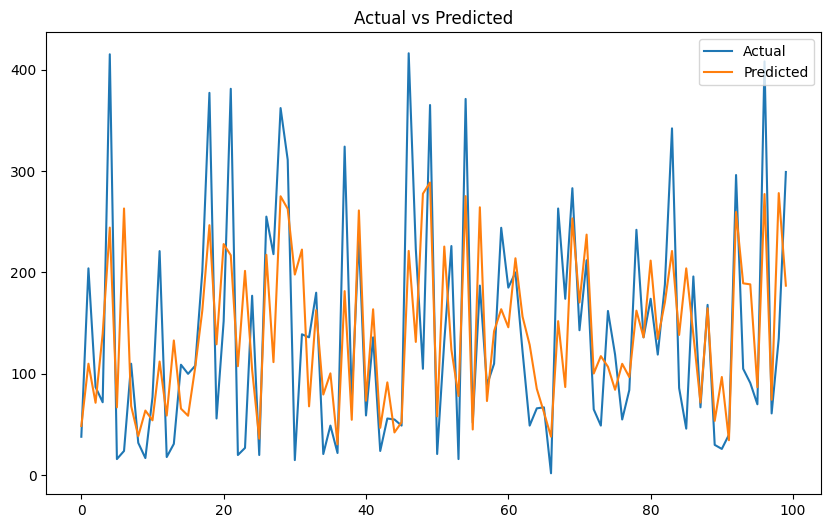

In [51]:
#visualization on predictions
plt.figure(figsize=(10,6))
plt.plot(Y_test[:100].reset_index(drop=True),label="Actual")
plt.plot(Y_pred[:100],label="Predicted")

plt.legend()
plt.title("Actual vs Predicted")
plt.show()